In [18]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import linear_model
from itertools import combinations
from sklearn.metrics import mean_squared_error

In [19]:
df = pd.read_csv("Training Set_11.csv",index_col=0)
df

,Exp_syn,Exp_anti,ΔΔG_Exp,ΔG_int,E(RwB97XD)_int,ΔH(RwB97XD)_int,SP_E(RwB97XD)_int,BL(C28-Pd),BL(C12-Pd),BA (C28-Pd-C12),...,E_dxz_Pd,E_dyz_Pd,E_dx2y2_Pd,E_dz2_Pd,E_Pd(LP)-C28(LP*),E_Pd(LP)-C12(LP*),E_C28(LP)-Pd(LP*),E_C12(LP)-Pd(LP*),Occ._Pd(LP),E_Pd(LP)
Ligand Name,,,,,,,,,,,,,,,,,,,,,
5-IMes,1.00,2.00,-0.484674,-1804.2453,-1804.7901,0.544791,-1806.2855,2.05604,1.98859,175.22297,...,-0.25111,-0.23408,-0.24280,-0.25121,31.60,61.84,221.94,251.94,1.73952,-0.23268
5-IMes(Me),1.00,1.80,-0.411002,-1882.8182,-1883.4157,0.597507,-1884.9254,2.05896,1.98482,175.14773,...,-0.24786,-0.23158,-0.24162,-0.24870,30.16,63.78,219.11,247.82,1.73538,-0.22952
5-IPr,1.80,1.00,0.411002,-2039.8947,-2040.6098,0.715108,-2042.1522,2.06852,1.98918,170.23798,...,-0.25299,-0.23952,-0.25146,-0.25613,29.49,62.57,198.12,226.10,1.73784,-0.23608
"5-IPr*(Me, Ph)",4.00,1.00,0.969348,-2884.9649,-2885.9336,0.968654,-2887.6474,2.07858,1.97721,165.88900,...,-0.26154,-0.25844,-0.26562,-0.25147,24.49,66.27,171.17,206.26,1.73388,-0.24368
5-IPr**,6.14,1.00,1.268993,-4908.3608,-4910.3959,2.035083,-4912.5098,2.07065,1.98778,167.42073,...,-0.26097,-0.25692,-0.25009,-0.25588,22.39,62.91,155.83,192.42,1.74199,-0.24136
5-IPr*,6.50,1.00,1.308833,-3651.4681,-3652.6320,1.163937,-3654.5018,2.07089,1.98778,165.42164,...,-0.26207,-0.26152,-0.26535,-0.24701,23.72,62.93,160.72,195.84,1.73997,-0.24433
5-SIMes,1.00,1.90,-0.448808,-1805.4289,-1805.9985,0.569576,-1807.4938,2.05731,1.99780,174.72873,...,-0.25051,-0.23458,-0.24228,-0.25078,31.91,58.51,225.06,242.92,1.74547,-0.23307
5-SIPr,2.60,1.00,0.668129,-2041.0793,-2041.8184,0.739147,-2043.3607,2.06240,1.99323,168.67786,...,-0.25536,-0.24060,-0.25102,-0.25734,28.48,60.30,197.82,219.37,1.74288,-0.23792
5-IXyOMe(Me),1.00,2.00,-0.484674,-2033.1753,-2033.7816,0.606229,-2035.3382,2.06151,1.98327,172.68660,...,-0.24790,-0.23160,-0.24083,-0.24860,28.88,64.84,217.95,247.51,1.73310,-0.22917


In [20]:
# Drop unwanted columns
df = df.drop(columns=["Exp_syn", "Exp_anti"])

In [21]:
df

,ΔΔG_Exp,ΔG_int,E(RwB97XD)_int,ΔH(RwB97XD)_int,SP_E(RwB97XD)_int,BL(C28-Pd),BL(C12-Pd),BA (C28-Pd-C12),BA(N-C-N),%Vbur(3.5Å),...,E_dxz_Pd,E_dyz_Pd,E_dx2y2_Pd,E_dz2_Pd,E_Pd(LP)-C28(LP*),E_Pd(LP)-C12(LP*),E_C28(LP)-Pd(LP*),E_C12(LP)-Pd(LP*),Occ._Pd(LP),E_Pd(LP)
Ligand Name,,,,,,,,,,,,,,,,,,,,,
5-IMes,-0.484674,-1804.2453,-1804.7901,0.544791,-1806.2855,2.05604,1.98859,175.22297,103.32507,37.6,...,-0.25111,-0.23408,-0.24280,-0.25121,31.60,61.84,221.94,251.94,1.73952,-0.23268
5-IMes(Me),-0.411002,-1882.8182,-1883.4157,0.597507,-1884.9254,2.05896,1.98482,175.14773,103.18288,37.4,...,-0.24786,-0.23158,-0.24162,-0.24870,30.16,63.78,219.11,247.82,1.73538,-0.22952
5-IPr,0.411002,-2039.8947,-2040.6098,0.715108,-2042.1522,2.06852,1.98918,170.23798,103.09034,45.5,...,-0.25299,-0.23952,-0.25146,-0.25613,29.49,62.57,198.12,226.10,1.73784,-0.23608
"5-IPr*(Me, Ph)",0.969348,-2884.9649,-2885.9336,0.968654,-2887.6474,2.07858,1.97721,165.88900,103.31600,49.4,...,-0.26154,-0.25844,-0.26562,-0.25147,24.49,66.27,171.17,206.26,1.73388,-0.24368
5-IPr**,1.268993,-4908.3608,-4910.3959,2.035083,-4912.5098,2.07065,1.98778,167.42073,103.44216,54.2,...,-0.26097,-0.25692,-0.25009,-0.25588,22.39,62.91,155.83,192.42,1.74199,-0.24136
5-IPr*,1.308833,-3651.4681,-3652.6320,1.163937,-3654.5018,2.07089,1.98778,165.42164,103.20629,54.2,...,-0.26207,-0.26152,-0.26535,-0.24701,23.72,62.93,160.72,195.84,1.73997,-0.24433
5-SIMes,-0.448808,-1805.4289,-1805.9985,0.569576,-1807.4938,2.05731,1.99780,174.72873,107.02035,38.4,...,-0.25051,-0.23458,-0.24228,-0.25078,31.91,58.51,225.06,242.92,1.74547,-0.23307
5-SIPr,0.668129,-2041.0793,-2041.8184,0.739147,-2043.3607,2.06240,1.99323,168.67786,106.56080,46.7,...,-0.25536,-0.24060,-0.25102,-0.25734,28.48,60.30,197.82,219.37,1.74288,-0.23792
5-IXyOMe(Me),-0.484674,-2033.1753,-2033.7816,0.606229,-2035.3382,2.06151,1.98327,172.68660,103.26705,37.8,...,-0.24790,-0.23160,-0.24083,-0.24860,28.88,64.84,217.95,247.51,1.73310,-0.22917


In [22]:
print(df.columns)

Index(['ΔΔG_Exp', 'ΔG_int', 'E(RwB97XD)_int', 'ΔH(RwB97XD)_int',
       'SP_E(RwB97XD)_int', 'BL(C28-Pd)', 'BL(C12-Pd)', 'BA (C28-Pd-C12)',
       'BA(N-C-N)', '%Vbur(3.5Å)', '%Vbur(4.0Å)', '%Vbur(3.0Å)', 'NPA (C28)',
       'NPA (C12)', 'NPA (Pd)', 'NPA (Cipso)', 'NPA (O)', 'MC(C28)', 'MC(C12)',
       'MC(Pd)', 'SP_MC(C28)', 'SP_MC(C12)', 'SP_MC(Pd)', 'MM_int', 'P(α)_int',
       'DM_int', 'DM(SP)_int', 'HC(Cv)_int', 'E(S)_int', 'Occ.(dxy)_Pd ',
       'Occ.(dxz)_Pd ', 'Occ.(dyz)_Pd', 'Occ.(dx2y2)_Pd', 'Occ.dz2)_Pd',
       'E_dxy_Pd', 'E_dxz_Pd', 'E_dyz_Pd', 'E_dx2y2_Pd', 'E_dz2_Pd',
       'E_Pd(LP)-C28(LP*)', 'E_Pd(LP)-C12(LP*)', 'E_C28(LP)-Pd(LP*)',
       'E_C12(LP)-Pd(LP*)', 'Occ._Pd(LP)', 'E_Pd(LP)'],
      dtype='str')


In [23]:
parm = ['ΔG_int', 'E(RwB97XD)_int', 'ΔH(RwB97XD)_int',
       'SP_E(RwB97XD)_int', 'BL(C28-Pd)', 'BL(C12-Pd)', 'BA (C28-Pd-C12)',
       'BA(N-C-N)', '%Vbur(3.5Å)', '%Vbur(4.0Å)', '%Vbur(3.0Å)', 'NPA (C28)',
       'NPA (C12)', 'NPA (Pd)', 'NPA (Cipso)', 'NPA (O)', 'MC(C28)', 'MC(C12)',
       'MC(Pd)', 'SP_MC(C28)', 'SP_MC(C12)', 'SP_MC(Pd)', 'MM_int', 'P(α)_int',
       'DM_int', 'DM(SP)_int', 'HC(Cv)_int', 'E(S)_int', 'Occ.(dxy)_Pd ',
       'Occ.(dxz)_Pd ', 'Occ.(dyz)_Pd', 'Occ.(dx2y2)_Pd', 'Occ.dz2)_Pd',
       'E_dxy_Pd', 'E_dxz_Pd', 'E_dyz_Pd', 'E_dx2y2_Pd', 'E_dz2_Pd',
       'E_Pd(LP)-C28(LP*)', 'E_Pd(LP)-C12(LP*)', 'E_C28(LP)-Pd(LP*)',
       'E_C12(LP)-Pd(LP*)', 'Occ._Pd(LP)', 'E_Pd(LP)']

In [24]:
for i in range (1, 3):
  for c in combinations(parm, i):
    x = df[list(c)]
    y = df['ΔΔG_Exp']
    regr = linear_model.LinearRegression()
    regr.fit(x,y)
    y_pred = regr.predict(x)
    r2 = regr.score(x,y)
    if r2 > 0.95:
      print(list(c))
      print("rmse =", mean_squared_error(y, y_pred))
      print("r2 =", regr.score(x,y))
      print(regr.coef_)
      print(regr.intercept_)
      print("")

['%Vbur(3.5Å)']
rmse = 0.007090824240466093
r2 = 0.9866418033374817
[0.10742617]
-4.466545254517918

['%Vbur(4.0Å)']
rmse = 0.00867645197946623
r2 = 0.983654685556416
[0.09607659]
-4.149697338938492

['%Vbur(3.0Å)']
rmse = 0.004488993856326696
r2 = 0.9915433155982856
[0.12236232]
-4.76960605384337

['NPA (C12)']
rmse = 0.017173833915745108
r2 = 0.9676467159365284
[-51.0632972]
14.6156532543897

['E_C12(LP)-Pd(LP*)']
rmse = 0.018207476985203433
r2 = 0.9656994659508532
[-0.03145654]
7.423719001299937

['ΔG_int', 'BA (C28-Pd-C12)']
rmse = 0.025151301230444234
r2 = 0.9526181982854467
[-0.00018866 -0.15248059]
25.83070169490505

['ΔG_int', '%Vbur(3.5Å)']
rmse = 0.005917799969038629
r2 = 0.9888516294981997
[6.82789484e-05 1.15644603e-01]
-4.654791739630549

['ΔG_int', '%Vbur(4.0Å)']
rmse = 0.007601407629286988
r2 = 0.9856799302055035
[6.54075588e-05 1.03130078e-01]
-4.307365672106249

['ΔG_int', '%Vbur(3.0Å)']
rmse = 0.003910282820505532
r2 = 0.9926335324144283
[4.66882676e-05 1.28679744e-01

In [25]:
first = "BL(C28-Pd)"

for second in parm:

    # Don't pair BL(C28–Pd) with itself
    if second == first:
        continue

    c = [first, second]

    x = df[c]
    y = df['ΔΔG_Exp']

    regr = linear_model.LinearRegression()
    regr.fit(x, y)

    y_pred = regr.predict(x)
    r2 = regr.score(x, y)

    # Print only models with R² > 0.95
    if r2 > 0.95:

        print("Descriptors:", c)
        print("MSE =", mean_squared_error(y, y_pred))
        print("R² =", r2)
        print("Coefficients =", regr.coef_)
        print("Intercept =", regr.intercept_)
        print("")

Descriptors: ['BL(C28-Pd)', '%Vbur(3.5Å)']
MSE = 0.004773725894700974
R² = 0.9910069172282601
Coefficients = [8.40636264 0.10111684]
Intercept = -21.549051973750203

Descriptors: ['BL(C28-Pd)', '%Vbur(4.0Å)']
MSE = 0.005862450709389605
R² = 0.9889559003516919
Coefficients = [9.21680089 0.08992138]
Intercept = -22.900910541469685

Descriptors: ['BL(C28-Pd)', '%Vbur(3.0Å)']
MSE = 0.0037618892701910055
R² = 0.9929130866892668
Coefficients = [4.83170767 0.11811156]
Intercept = -14.573002558257306

Descriptors: ['BL(C28-Pd)', 'NPA (C12)']
MSE = 0.017173495250589952
R² = 0.9676473539379218
Coefficients = [  0.10947196 -51.02050949]
Intercept = 14.377545346390328

Descriptors: ['BL(C28-Pd)', 'E_C12(LP)-Pd(LP*)']
MSE = 0.011040883480126128
R² = 0.9792004021177403
Coefficients = [14.23084429 -0.02846023]
Intercept = -22.646595148877285



BL(C28-Pd) + %Vbur(3.5Å): R² = 0.991
BL(C28-Pd) + %Vbur(4.0Å): R² = 0.989
BL(C28-Pd) + %Vbur(3.0Å): R² = 0.993
BL(C28-Pd) + NPA (C12): R² = 0.968
BL(C28-Pd) + E_C12(LP)-Pd(LP*): R² = 0.979


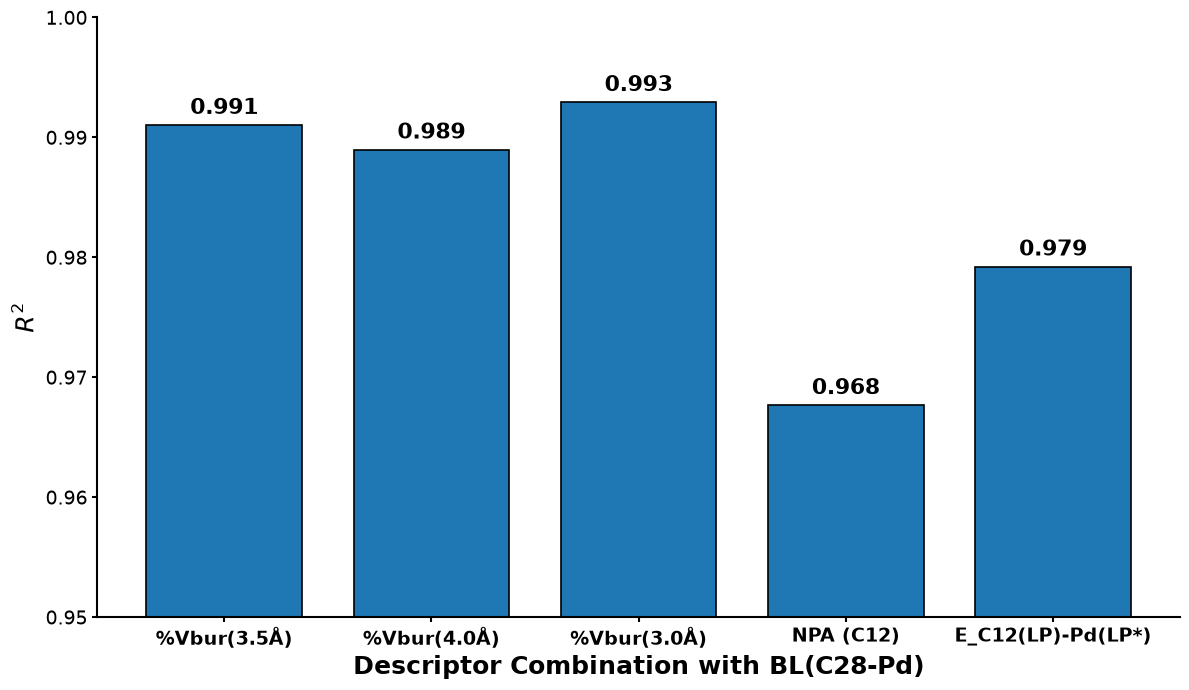

In [26]:
# ============================================================
# Fixed descriptor
# ============================================================
first = "BL(C28-Pd)"

# ============================================================
# Find all bivariate combinations with R² > 0.95
# ============================================================
results = []

for second in parm:

    # Do not combine BL(C28–Pd) with itself
    if second == first:
        continue

    c = [first, second]

    x = df[c]
    y = df['ΔΔG_Exp']

    regr = linear_model.LinearRegression()
    regr.fit(x, y)

    y_pred = regr.predict(x)

    r2 = regr.score(x, y)

    # Keep only R² > 0.95
    if r2 > 0.95:

        results.append({
            "descriptor": second,
            "R2": r2,
            "MSE": mean_squared_error(y, y_pred),
            "coef_BL": regr.coef_[0],
            "coef_second": regr.coef_[1],
            "intercept": regr.intercept_
        })

# ============================================================
# Print results
# ============================================================
for result in results:
    print(
        f"BL(C28-Pd) + {result['descriptor']}: "
        f"R² = {result['R2']:.3f}"
    )

# ============================================================
# Prepare data for plotting
# ============================================================
descriptors = [r["descriptor"] for r in results]
r2_values = [r["R2"] for r in results]

# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.bar(
    range(len(descriptors)),
    r2_values,
    width=0.75,
    edgecolor="black",
    linewidth=1.2
)

# ============================================================
# R² values above bars
# ============================================================
for bar, r2 in zip(bars, r2_values):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0005,
        f"{r2:.3f}",
        ha="center",
        va="bottom",
        fontsize=16,
        fontweight="bold"
    )

# ============================================================
# X-axis
# ============================================================
ax.set_xticks(range(len(descriptors)))
ax.set_xticklabels(
    descriptors,
    fontsize=14,
    fontweight="bold",
    rotation=0
)

# ============================================================
# Y-axis
# ============================================================
ax.set_ylabel(r"$R^2$", fontsize=18, fontweight="bold")

ax.set_ylim(0.95, 1.000)

# ============================================================
# X-axis label
# ============================================================
ax.set_xlabel(
    "Descriptor Combination with BL(C28-Pd)",
    fontsize=18,
    fontweight="bold"
)

# ============================================================
# Tick formatting
# ============================================================
ax.tick_params(
    axis="y",
    labelsize=14,
    width=1.5
)

ax.tick_params(
    axis="x",
    width=1.5
)

# ============================================================
# Spine formatting
# ============================================================
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

plt.tight_layout()

plt.show()